# Modelli Generativi Profondi: Convolutional VAE

Questo notebook esplora i **modelli generativi profondi** applicati alla ricostruzione e alla generazione di immagini medicali.
Il modello implementato è un **Convolutional Variational Autoencoder (ConvVAE)**, che si distingue dalle architetture
puramente ricostruttive (U-Net, ResCNN) studiate nei notebook precedenti per la sua capacità di apprendere una
**distribuzione latente** strutturata e, di conseguenza, di *generare* nuovi campioni realistici.

Riferimento: [Deep Generative Models — Computational Imaging](https://devangelista2.github.io/computational-imaging/2025-26/generative/vaes-and-gans.html)

---

## Blocco 1 — Importazioni, dataset e utilità

Nel primo blocco di codice vengono eseguite le seguenti operazioni:

1. **Importazione delle librerie** necessarie: PyTorch, `torchvision`, `matplotlib`, `tqdm` e il modulo `IPPy`.
2. **Definizione della classe `MayoDataset`**, un `Dataset` PyTorch che:
   - legge tutte le immagini PNG dal percorso indicato;
   - le converte in scala di grigi;
   - le ridimensiona a 64×64 pixel.
3. **Funzione `show_batch`** di utilità per visualizzare un batch di immagini in una griglia.
4. **Rilevamento automatico del device** (`mps` su Apple Silicon, `cuda` o `cpu`).
5. **Creazione di `DataLoader`** di training e test con batch size 32.
6. **Visualizzazione** di 8 slice di esempio dal training set.

**Output atteso:** stampa del device utilizzato, numero di immagini di training/test, percorso pesi,
e un plot con 8 immagini di esempio ridimensionate a 64×64.

Device: mps
Training images: 3306
Test images: 327
Weights directory: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights


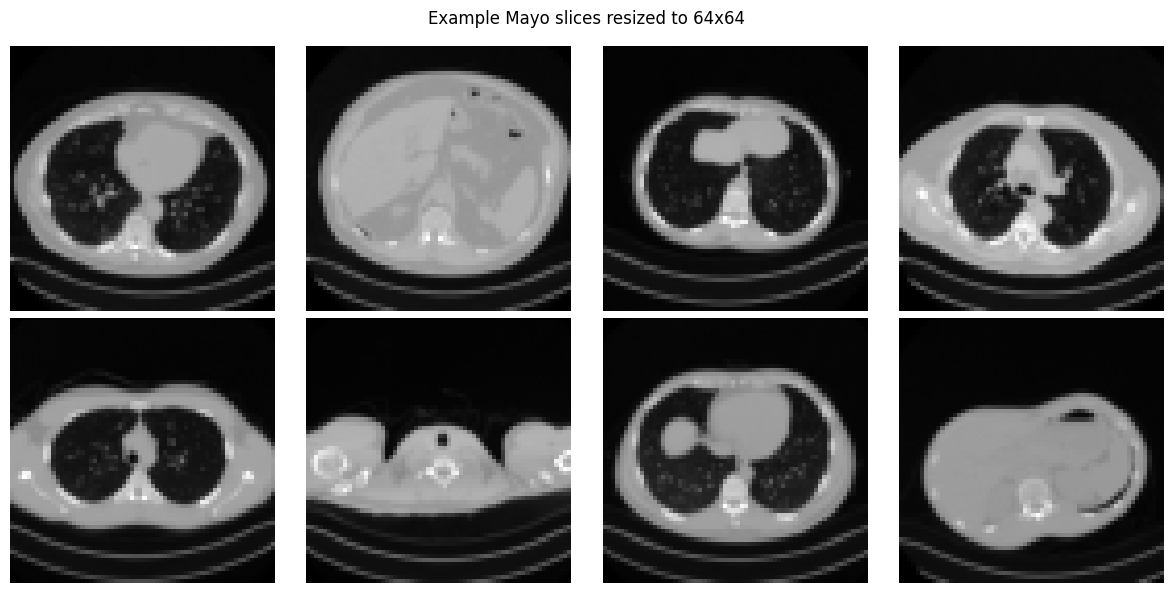

In [ ]:
import glob
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm

sys.path.append('..')
from IPPy import operators, utilities

book_root = Path('').resolve()
weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)


class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((data_shape, data_shape)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


def show_batch(batch, title, ncols=4):
    batch = batch.detach().cpu()
    n = min(len(batch), 8)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.reshape(-1) if hasattr(axes, 'reshape') else [axes]
    for ax, image in zip(axes, batch[:n]):
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


device = utilities.get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=64)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=64)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

x_batch = next(iter(train_loader))
show_batch(x_batch[:8], 'Example Mayo slices resized to 64x64')

---

## Blocco 2 — Componenti base dell'architettura

Qui vengono definiti i **blocchi fondamentali** con cui è costruito il ConvVAE.

### `norm_layer(channels)`
Funzione helper che restituisce un layer di **Group Normalization** (`nn.GroupNorm`).
La Group Norm è preferita alla classica Batch Normalization perché funziona bene anche
con batch molto piccoli.

### `ResidualBlock(channels)`
Implementa una **connessione residua** (skip connection) del tipo $y = x + F(x)$, dove $F$ è composto
da due convoluzioni 3×3 intervallate da Group Norm e attivazione SiLU.

- La connessione residua stabilizza l'addestramento delle reti profonde e facilita il flusso del gradiente.
- È lo stesso principio alla base del *residual learning* studiato nel notebook sulle ResCNN,
  ma qui viene usato all'interno di un'architettura generativa.

### `DownBlock(in_ch, out_ch)`
Blocco di **downsampling**:

- Convoluzione 4×4 con stride 2 (dimezza la risoluzione spaziale).
- Group Norm + SiLU.
- Un `ResidualBlock` per raffinare le feature.

### `UpsampleBlock(in_ch, out_ch)`
Blocco di **upsampling**:

- `nn.Upsample` bilineare con fattore 2 (raddoppia la risoluzione).
- Convoluzione 3×3 per ri-proiettare i canali.
- Group Norm + SiLU + `ResidualBlock`.

> **Nota sulla differenza con U-Net:** nella U-Net classica, i blocchi di upsampling ricevono
> le feature maps dall'encoder tramite *skip connection* a livello di layer (concatenazione).
> Nel VAE, invece, **non esistono skip connection tra encoder e decoder**, perché tutta
> l'informazione deve passare attraverso il *bottleneck* latente $z$. Questo è fondamentale
> affinché lo spazio latente apprenda una rappresentazione significativa dei dati.

In [3]:
def norm_layer(channels):
    num_groups = 8 if channels >= 8 else 1
    return nn.GroupNorm(num_groups=num_groups, num_channels=channels)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            norm_layer(channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            norm_layer(channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            norm_layer(out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            norm_layer(out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )

    def forward(self, x):
        return self.block(x)

## Blocco 3 — Modello `ConvVAE`

Questa cella definisce il cuore del notebook: il **Convolutional Variational Autoencoder**.

### Architettura

| Componente | Dettaglio |
|---|---|
| **Stem** | Conv 3×3 + GroupNorm + SiLU + ResidualBlock — estrae le prime feature dall'immagine 64×64 |
| **Encoder** | 4 `DownBlock` successivi: 32→64→128→256→512 canali; la risoluzione scende a 4×4 |
| **Bottleneck lineare** | Due layer lineari (`fc_mu`, `fc_logvar`) mappano il vettore appiattito 512×4×4 = 8192 → `latent_dim` (default 64) |
| **Reparameterization trick** | $z = \mu + \varepsilon \cdot \sigma$, dove $\varepsilon \sim \mathcal{N}(0, I)$ — permette la retro-propagazione attraverso il campionamento |
| **Decoder lineare** | `fc_decode` mappa `latent_dim` → 8192, poi reshape a (512, 4, 4) |
| **Decoder conv.** | 4 `UpsampleBlock` successivi: 512→256→128→64→32 canali |
| **Output** | Conv 3×3 finale + Sigmoid → immagine ricostruita in [0,1] |

### Metodi principali

- **`encode(x)`** → `(mu, logvar)`: calcola i parametri della distribuzione approssimata 
$q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2 I)$.
  Il `logvar` è clampato in $[-4.5, 1.0]$ per stabilità numerica.
- **`reparameterize(mu, logvar)`** → `z`: applica il reparameterization trick.
- **`decode(z)`** → `x̂`: genera un'immagine dallo spazio latente.
- **`reconstruct_deterministic(x)`** → `x̂`: ricostruisce usando solo $\mu$ (senza campionamento),
  utile nella fase 1 di pre-training deterministico.
- **`forward(x)`** → `(x̂, mu, logvar)`: pipeline completa encoder → reparameterize → decoder.

### Differenze architetturali rispetto a U-Net e ResCNN

| Aspetto | U-Net / ResCNN | ConvVAE |
|---|---|---|
| **Obiettivo** | Ricostruzione deterministica (deblurring, denoising) | Apprendere una distribuzione latente + generazione |
| **Skip connections encoder↔decoder** | Sì (concatenazione o somma) | **No** — tutta l'informazione deve passare da $z$ |
| **Bottleneck** | Feature maps spaziali (nessun layer fully-connected) | Vettore latente $z \in \mathbb{R}^{d}$ tramite layer lineari |
| **Campionamento** | Assente | Reparameterization trick ($ z \sim q_{\phi(z┃x)}$) |
| **Funzione di attivazione finale** | Nessuna (output diretto) o ReLU | **Sigmoid** (per vincolare l'output in [0, 1]) |
| **Loss function** | Pixel-wise (MSE, L1) | Ricostruzione + **KL divergence** |
| **Generazione** | Non possibile | Possibile campionando $z \sim \mathcal{N}(0, I)$ |

In [4]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            norm_layer(32),
            nn.SiLU(),
            ResidualBlock(32),
        )
        self.down1 = DownBlock(32, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)

        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 512 * 4 * 4)

        self.up1 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up3 = UpsampleBlock(128, 64)
        self.up4 = UpsampleBlock(64, 32)
        self.out_conv = nn.Sequential(
            norm_layer(32),
            nn.SiLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.stem(x)
        h = self.down1(h)
        h = self.down2(h)
        h = self.down3(h)
        h = self.down4(h)
        h = h.flatten(start_dim=1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(min=-4.5, max=1.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(z.shape[0], 512, 4, 4)
        h = self.up1(h)
        h = self.up2(h)
        h = self.up3(h)
        h = self.up4(h)
        return self.out_conv(h)

    def reconstruct_deterministic(self, x):
        mu, _ = self.encode(x)
        return self.decode(mu)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

---

## Blocco 4 — Funzione di perdita del VAE

Viene definita la **funzione di perdita** `vae_loss`, elemento chiave che distingue il VAE
da un semplice AutoEncoder.

### Composizione della loss

$$\mathcal{L} = \underbrace{\|\hat x - x\|_1 + 0.1 \cdot \|\hat x - x\|_2^2}_{\text{ricostruzione}} \;+\; \gamma \cdot \big|\,\text{KL}\bigl(q_\phi(z|x) \| \mathcal{N}(0,I)\bigr) - C\,\big|$$

1. **Termine di ricostruzione:** combinazione di L1 (robusta agli outlier) e MSE (penalizza errori grandi),
   analogamente a quanto si fa in U-Net/ResCNN, ma qui pesa su immagini generate dallo spazio latente.
2. **KL divergence:** misura quanto la distribuzione approssimata $q_\phi(z|x)$ si discosta dalla prior $\mathcal{N}(0,I)$.
   Questo termine è **esclusivo dei modelli variazionali** e non ha equivalente in U-Net o ResCNN.
3. **Capacity $C$:** il valore assoluto $|\text{KL} - C|$ implementa il meccanismo di *latent capacity*,
   che consente alla rete di aumentare gradualmente la quantità di informazione codificata nello spazio latente
   durante il training (vedi Stage 2).

**Output dei valori intermedi:** la funzione restituisce `(loss, recon, kl)` per consentire
il monitoraggio separato dei due contributi durante l'addestramento.

In [5]:

def vae_loss(x_hat, x, mu, logvar, gamma=5e-4, capacity=0.0):
    recon_l1 = F.l1_loss(x_hat, x)
    recon_mse = F.mse_loss(x_hat, x)
    recon = recon_l1 + 0.1 * recon_mse
    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    kl = kl_per_sample.mean()
    loss = recon + gamma * torch.abs(kl - capacity)
    return loss, recon, kl

---

## Blocco 5 — Fase 1: Pre-training deterministico (AutoEncoder)

L'addestramento del ConvVAE è suddiviso in **due fasi** (*two-stage training*), una strategia
empirica che migliora significativamente la qualità delle ricostruzioni:

### Stage 1 — AutoEncoder deterministico

- Il modello viene addestrato **senza campionamento** e **senza KL divergence**.
- Si utilizza il metodo `reconstruct_deterministic(x)`, che codifica l'immagine e decodifica
  direttamente da $\mu$, ignorando $\log\sigma^2$ e il reparameterization trick.
- La loss è puramente ricostruttiva: L1 + 0.1·MSE.
- Ottimizzatore: Adam con learning rate $10^{-3}$.
- Numero di epoche: 10.

**Motivazione:** questo pre-training permette all'encoder e al decoder di imparare una buona mappatura
input→output *prima* di introdurre il rumore stocastico del campionamento. In pratica, la rete
si comporta inizialmente come una ResCNN/U-Net (ricostruzione deterministica), per poi essere
convertita in un vero modello generativo nella Fase 2.

**Output atteso:** barra di avanzamento `tqdm` con loss media per epoca.
I valori di loss dovrebbero diminuire progressivamente.

In [6]:
torch.manual_seed(0)

latent_dim = 64
vae = ConvVAE(latent_dim=latent_dim).to(device)
pretrain_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
finetune_optimizer = torch.optim.Adam(vae.parameters(), lr=3e-4)
pretrain_epochs = 10
finetune_epochs = 40
vae_history = []
vae_path = weights_dir / 'VAE.pth'

# Stage 1: deterministic AutoEncoder pretraining
for epoch in range(pretrain_epochs):
    vae.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'AE pretrain {epoch + 1}/{pretrain_epochs}', leave=True)

    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)
        x_rec = vae.reconstruct_deterministic(x_batch)
        loss = F.l1_loss(x_rec, x_batch) + 0.1 * F.mse_loss(x_rec, x_batch)

        pretrain_optimizer.zero_grad()
        loss.backward()
        pretrain_optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f'{loss.item():.5f}', avg=f'{epoch_loss / step:.5f}')

    vae_history.append(epoch_loss / len(train_loader))

AE pretrain 1/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 2/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 3/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 4/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 5/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 6/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 7/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 8/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 9/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 10/10:   0%|          | 0/104 [00:00<?, ?it/s]

---

## Blocco 6 — Fase 2: Fine-tuning variazionale + valutazione

### Stage 2 — VAE con *latent capacity control*

- Si attiva ora la **pipeline completa** del VAE: `forward(x)` → campionamento → decodifica.
- La loss include la **KL divergence** con il meccanismo di capacity:
  la soglia $C$ cresce linearmente da 0 a 12 durante le 40 epoche, consentendo alla rete
  di utilizzare progressivamente maggiore informazione nello spazio latente.
- Ottimizzatore: Adam con learning rate $3 \times 10^{-4}$ (più basso per stabilità).

### Valutazione finale

Al termine dell'addestramento:

1. I pesi del modello vengono **salvati** e **ricaricati** per verificare la persistenza.
2. Vengono prodotte tre righe di immagini:
   - **Target:** immagini originali dal test set.
   - **Recon.:** ricostruzioni ottenute dall'encoder + decoder (passando per $z$).
   - **Sample:** immagini **generate da zero** campionando $z \sim \mathcal{N}(0, I)$.
3. Vengono stampate statistiche sulla distribuzione a posteriori ($\mu$, $\sigma$).
4. Viene tracciata la **curva di loss** sulle 50 epoche totali (10 pretrain + 40 finetune).

**Output atteso:**
- Barre di avanzamento con loss, ricostruzione e KL ad ogni step.
- Un plot 3×8 con target, ricostruzioni e campioni generati.
- Un grafico della loss che mostra un leggero "salto" al passaggio dalla Fase 1 alla Fase 2
  (dovuto all'introduzione della KL divergence).

---

## Riepilogo: VAE vs. architetture ricostruttive

| Caratteristica | U-Net / ResCNN (notebook precedenti) | ConvVAE (questo notebook) |
|---|---|---|
| **Tipo di modello** | Discriminativo / ricostruttivo | **Generativo** |
| **Training** | Singola fase, loss pixel-wise | **Due fasi:** pretrain deterministico + finetune variazionale |
| **Spazio latente** | Non esplicito | Vettore $z$ con distribuzione appresa ($\mu$, $\sigma$) |
| **Generazione** | ✗ | ✓ — campionando $z \sim \mathcal{N}(0, I)$ |
| **Skip connections** | Sì (cross-layer) | No (bottleneck obbligatorio) |
| **Normalizzazione** | Batch Norm | **Group Norm** (robusta a batch piccoli) |
| **Attivazione** | ReLU / LeakyReLU | **SiLU** (Swish — più liscia, migliore in reti generative) |

VAE finetune 1/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 2/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 3/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 4/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 5/40:   0%|          | 0/104 [00:00<?, ?it/s]

...

VAE finetune 37/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 38/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 39/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 40/40:   0%|          | 0/104 [00:00<?, ?it/s]

Saved VAE weights to: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights/VAE.pth
Posterior mean std: 0.389
Posterior std mean: 0.902


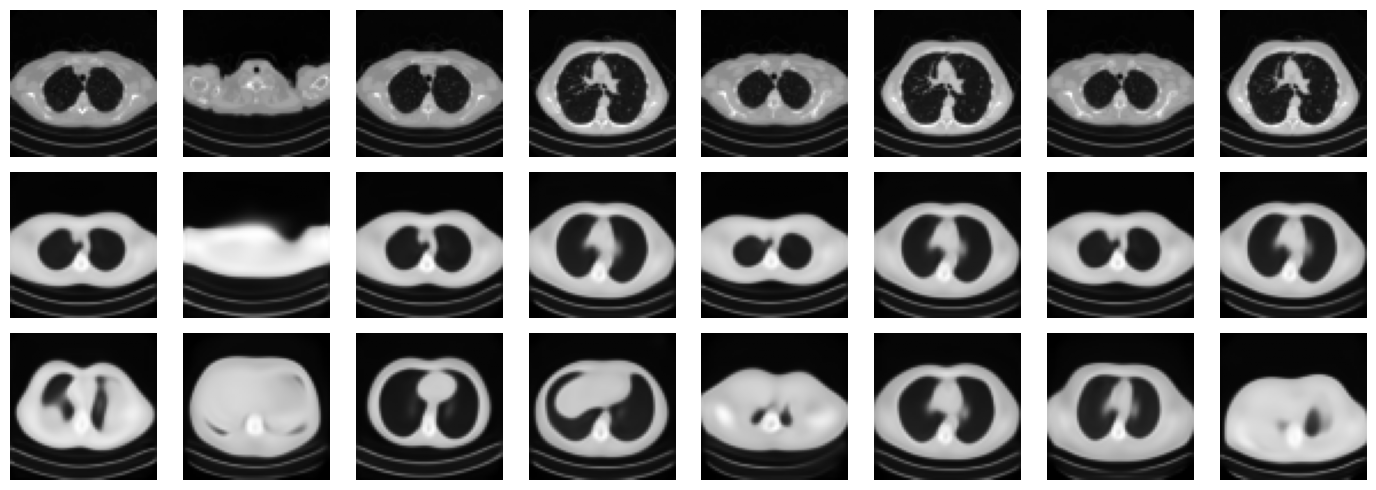

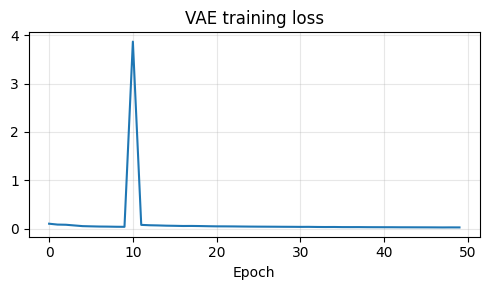

In [7]:
# Stage 2: variational fine-tuning with latent-capacity control
for epoch in range(finetune_epochs):
    vae.train()
    epoch_loss = 0.0
    capacity = min(12.0, (epoch + 1) / finetune_epochs * 12.0)
    progress_bar = tqdm(train_loader, desc=f'VAE finetune {epoch + 1}/{finetune_epochs}', leave=True)

    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)
        x_rec, mu, logvar = vae(x_batch)
        loss, recon, kl = vae_loss(x_rec, x_batch, mu, logvar, gamma=5e-4, capacity=capacity)

        finetune_optimizer.zero_grad()
        loss.backward()
        finetune_optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f'{loss.item():.5f}', recon=f'{recon.item():.5f}', kl=f'{kl.item():.3f}', cap=f'{capacity:.2f}')

    vae_history.append(epoch_loss / len(train_loader))

torch.save(vae.state_dict(), vae_path)
print(f'Saved VAE weights to: {vae_path}')

reloaded_vae = ConvVAE(latent_dim=latent_dim)
reloaded_vae.load_state_dict(torch.load(vae_path, map_location='cpu', weights_only=True))
reloaded_vae = reloaded_vae.to(device)
reloaded_vae.eval()

with torch.no_grad():
    x_vis = next(iter(test_loader))[:8].to(device)
    x_rec, mu_vis, logvar_vis = reloaded_vae(x_vis)
    z = torch.randn(8, latent_dim, device=device)
    x_gen = reloaded_vae.decode(z)
    posterior_std = torch.exp(0.5 * logvar_vis)

print(f'Posterior mean std: {mu_vis.std().item():.3f}')
print(f'Posterior std mean: {posterior_std.mean().item():.3f}')

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for i in range(8):
    axes[0, i].imshow(x_vis[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_rec[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(x_gen[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')
axes[0, 0].set_ylabel('Target', rotation=0, labelpad=30)
axes[1, 0].set_ylabel('Recon.', rotation=0, labelpad=30)
axes[2, 0].set_ylabel('Sample', rotation=0, labelpad=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(vae_history)
plt.title('VAE training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()